# Ordinal Data
Feature reduction, redundancy and feature engineering

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

data = pd.read_csv("Data/ordinal_train_cleaned.csv")
X = data.drop('SalePrice', axis=1)
y = data['SalePrice']

X

,OverallQual,OverallQual.1,OverallCond,MSSubClass,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,...,HeatingQC,KitchenQual,FireplaceQu,GarageFinish,GarageQual,GarageCond,LotShape,LandSlope,LandContour,SaleCondition
0,7,7,5,60,4,3,4,3,1,6,...,5,4,4,2,3,3,3,2,3,4
1,6,6,8,20,3,3,4,3,4,5,...,5,3,3,2,3,3,3,2,3,4
2,7,7,5,60,4,3,4,3,2,6,...,5,4,3,2,3,3,2,2,3,4
3,7,7,5,70,3,3,3,4,1,5,...,4,4,4,1,3,3,2,2,3,0
4,8,8,5,60,4,3,4,3,3,6,...,5,4,3,2,3,3,2,2,3,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1407,6,6,5,60,3,3,4,3,1,1,...,5,3,3,2,3,3,3,2,3,4
1408,6,6,6,20,3,3,4,3,1,5,...,3,3,3,1,3,3,3,2,3,4
1409,7,7,9,70,5,4,3,4,1,6,...,5,4,4,2,3,3,3,2,3,4
1410,5,5,6,20,3,3,3,3,2,6,...,4,4,4,1,3,3,3,2,3,4


# Mutual Information Score
as first feature reduction criterion

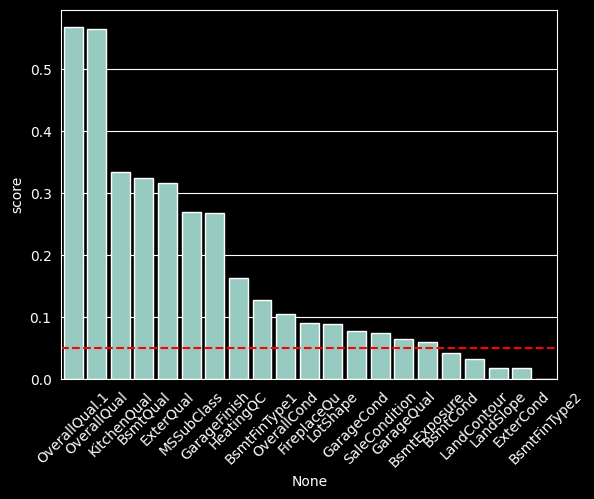

In [11]:
from sklearn.feature_selection import mutual_info_regression

mi = mutual_info_regression(X, y)
mi_series = pd.Series(mi, index=X.columns, name='score').sort_values(ascending=False)

sns.barplot(x=mi_series.index, y=mi_series.sort_values(ascending=False))
plt.xticks(rotation=45)
plt.axhline(y=0.05, color='r', linestyle='--')
plt.show()

And We take those having MI score grater than 0.05

In [13]:
selected_X = X[mi_series[mi_series.values > 0.05].keys()]
selected_X

,OverallQual.1,OverallQual,KitchenQual,BsmtQual,ExterQual,MSSubClass,GarageFinish,HeatingQC,BsmtFinType1,OverallCond,FireplaceQu,LotShape,GarageCond,SaleCondition,GarageQual,BsmtExposure
0,7,7,4,4,4,60,2,5,6,5,4,3,3,4,3,1
1,6,6,3,4,3,20,2,5,5,8,3,3,3,4,3,4
2,7,7,4,4,4,60,2,5,6,5,3,2,3,4,3,2
3,7,7,4,3,3,70,1,4,5,5,4,2,3,0,3,1
4,8,8,4,4,4,60,2,5,6,5,3,2,3,4,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1407,6,6,3,4,3,60,2,5,1,5,3,3,3,4,3,1
1408,6,6,3,4,3,20,1,3,5,6,3,3,3,4,3,1
1409,7,7,4,3,5,70,2,5,6,9,4,3,3,4,3,1
1410,5,5,4,3,3,20,1,4,6,6,4,3,3,4,3,2


# PCA Analysis

In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=4)

pca.fit(selected_X)


df_components = pd.DataFrame()
pca.components_

array([[ 1.25309806e-03,  1.25309806e-03, -1.10895952e-04,
         1.32295165e-03,  3.23031056e-04,  9.99990739e-01,
        -5.21744380e-04, -1.29810131e-04,  1.65273770e-03,
        -1.66152368e-03, -1.44984883e-04,  1.57173990e-03,
        -1.31490340e-03, -6.32967084e-04, -9.94205666e-04,
         1.45752764e-03],
       [ 4.61392830e-01,  4.61392830e-01,  1.83857915e-01,
         1.98035349e-01,  1.65714008e-01, -2.20593355e-03,
         2.32849537e-01,  1.91558357e-01,  5.52819197e-01,
        -7.18553859e-02, -3.16010820e-03, -5.83755336e-02,
         1.02454254e-01,  1.13338271e-01,  1.04976878e-01,
         1.85147339e-01],
       [-3.58100878e-01, -3.58100878e-01, -1.02412879e-01,
        -8.89907895e-02, -1.07458337e-01, -5.86755193e-04,
        -1.13002107e-01, -1.33681700e-01,  8.14068189e-01,
         4.75970446e-02, -2.84527113e-02,  1.77937467e-02,
        -4.34070249e-02, -9.64504753e-02, -4.52993434e-02,
         5.99523791e-02],
       [-4.17942045e-02, -4.17942045e